---
date: "2026-07-19"
date-modified: last-modified
format:
  html:
    toc: true
---


# Gamma Function and Distribution

The **[Gamma function]()** $\Gamma(a)$ is one of the most fundamental Eulerian integral functions in mathematics, acting as the continuous generalization of the factorial function to non-integral real and complex arguments. In probability theory and mathematical statistics, the Gamma function provides the normalizing constant for the **[Gamma Distribution](gamma-function-and-distribution.ipynb)**, a versatile two-parameter family of continuous probability distributions over the positive real line.

Through its connections with **[Stirling's Approximation]()**, **[Poisson Processes](poisson-distribution.ipynb)**, and the **[Beta Distribution](beta-distribution.ipynb)**, the Gamma family forms the structural backbone for modeling continuous waiting times, continuous analogues of discrete counting processes, and order statistics.

---

## Overview of Key Topics

1. **The Gamma Function:** Integral definition, recurrence relations, half-integer evaluations, and [Stirling's Approximation]().
2. **The Gamma Distribution:** Shape-rate parameterization, density normalization, and linear scaling transformations.
3. **Gamma-Exponential Connection:** Continuous waiting times, arrival processes, and the MGF identity for sums of independent exponentials.
4. **Moments via LOTUS:** Elegant derivations of raw moments, mean, and variance utilizing the [Law of the Unconscious Statistician (LOTUS)](lotus.ipynb).
5. **The Beta-Gamma Connection:** The celebrated Bank and Post Office Theorem establishing the exact independence of total waiting times and fractional allocations via 2D Jacobian transformations.

## 1\. The Gamma Function and Stirling's Approximation

To extend the factorial relation $n! = n \times (n-1) \times \dots \times 1$ from the positive integers $\mathbb{N}$ to the positive real numbers $\mathbb{R}^+$, we examine the Euler integral of the second kind.

::: {#def-gamma-function}
## The Gamma Function
For any real number $a > 0$ (and more generally for complex numbers with positive real part $\text{Re}(a) > 0$), the **Gamma function** $\Gamma(a)$ is defined by the improper integral:
$$
\Gamma(a) = \int_0^\infty x^a e^{-x} \frac{dx}{x} = \int_0^\infty x^{a-1} e^{-x} dx
$$
:::

::: {.callout-note}
## Intuition: Multiplicative Haar Measure vs. Standard Lebesgue Measure
In the definition above, writing the integrand as $x^a e^{-x} \frac{dx}{x}$ explicitly highlights $\frac{dx}{x}$ as the **multiplicative Haar measure** on the positive real line $(0, \infty)$. Under this viewpoint, the Gamma function is the Mellin transform of the negative exponential function $e^{-x}$. Writing it in the standard form $x^{a-1} e^{-x} dx$ is the canonical representation used throughout classical probability density derivations.
:::

When evaluating factorials or Gamma functions for large arguments where direct computation overflows standard floating-point precision, asymptotic approximations become indispensable.

::: {#thm-stirlings-approx}
## Stirling's Approximation
For large positive values of $n$, the factorial function and the Gamma function grow asymptotically according to the formula:
$$
n! = \Gamma(n+1) \approx \sqrt{2\pi n} \left(\frac{n}{e}\right)^n
$$
More formally, the relative error converges to zero as $n \to \infty$:
$$
\lim_{n \to \infty} \frac{n!}{\sqrt{2\pi n} (n/e)^n} = 1
$$
:::

### 1.1\. Fundamental Properties and Special Values

The defining characteristic of the Gamma function is its recurrence relation, which directly mirrors the factorial recursion $(n)! = n (n-1)!$.

::: {#thm-gamma-recurrence}
## Gamma Recurrence Relation and Factorial Identity
For any real number $x > 0$, the Gamma function satisfies the fundamental recurrence:
$$
\Gamma(x+1) = x \Gamma(x)
$$
Furthermore, for any positive integer $n \in \mathbb{N}$:
$$
\Gamma(n) = (n-1)!
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Gamma Recurrence and Factorial Identity
We apply the method of [integration by parts]() to the definition $\Gamma(x+1) = \int_0^\infty t^x e^{-t} dt$.

Let our parts be chosen as follows:
$$
\begin{aligned}
u &= t^x & dv &= e^{-t} dt \\
du &= x t^{x-1} dt & v &= -e^{-t}
\end{aligned}
$$

Applying the integration by parts formula $\int_0^\infty u \, dv = [uv]_0^\infty - \int_0^\infty v \, du$, we obtain:
$$
\begin{aligned}
\Gamma(x+1) &= \left[ -t^x e^{-t} \right]_0^\infty - \int_0^\infty (-e^{-t}) (x t^{x-1}) dt \\
&= \left( \lim_{t \to \infty} \frac{-t^x}{e^t} - 0 \right) + x \int_0^\infty t^{x-1} e^{-t} dt
\end{aligned}
$$

Since the exponential function $e^t$ grows faster than any polynomial power $t^x$ as $t \to \infty$, by repeated application of L'Hôpital's rule we have $\lim_{t \to \infty} t^x e^{-t} = 0$. Thus, the boundary term vanishes entirely:
$$
\Gamma(x+1) = x \int_0^\infty t^{x-1} e^{-t} dt = x \Gamma(x)
$$

To establish the identity for positive integers $n \in \mathbb{N}$, we first compute the base case $\Gamma(1)$:
$$
\Gamma(1) = \int_0^\infty t^{1-1} e^{-t} dt = \int_0^\infty e^{-t} dt = \left[ -e^{-t} \right]_0^\infty = 0 - (-1) = 1
$$

By mathematical induction on $n$:
- For $n = 1$, $\Gamma(1) = 1 = 0!$.
- Assuming $\Gamma(k) = (k-1)!$ holds for some integer $k \ge 1$, we apply the recurrence relation for $x = k$:
$$
\Gamma(k+1) = k \Gamma(k) = k \times (k-1)! = k!
$$
Thus, $\Gamma(n) = (n-1)!$ for all positive integers $n \in \mathbb{N}$. $\blacksquare$
:::

In addition to integer arguments, the Gamma function evaluates to closed-form algebraic multiples of $\sqrt{\pi}$ at half-integer values.

::: {#prp-gamma-half-integer}
## Half-Integer Gamma Evaluations
At the fundamental half-integer argument $a = 1/2$, the Gamma function evaluates exactly to:
$$
\Gamma\left(\frac{1}{2}\right) = \sqrt{\pi}
$$
Successive half-integer evaluations follow directly via the recurrence relation:
$$
\Gamma\left(\frac{3}{2}\right) = \frac{\sqrt{\pi}}{2}, \quad \Gamma\left(\frac{5}{2}\right) = \frac{3\sqrt{\pi}}{4}, \quad \Gamma\left(\frac{2n+1}{2}\right) = \frac{(2n)!}{4^n n!} \sqrt{\pi}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Half-Integer Gamma Values
We begin with the definition of $\Gamma(1/2)$:
$$
\Gamma\left(\frac{1}{2}\right) = \int_0^\infty x^{-1/2} e^{-x} dx
$$

We introduce the change of variables $x = u^2$. Then, for $x > 0$ and $u > 0$:
$$
\begin{aligned}
u &= \sqrt{x} \\
dx &= 2u \, du
\end{aligned}
$$

Substituting this transformation into the integral yields:
$$
\begin{aligned}
\Gamma\left(\frac{1}{2}\right) &= \int_0^\infty (u^2)^{-1/2} e^{-u^2} (2u \, du) \\
&= \int_0^\infty \frac{1}{u} e^{-u^2} (2u \, du) \\
&= 2 \int_0^\infty e^{-u^2} du
\end{aligned}
$$

Since the integrand $e^{-u^2}$ is an even function across the real line, we can extend the integration over the entire real domain $(-\infty, \infty)$ by symmetry:
$$
\Gamma\left(\frac{1}{2}\right) = \int_{-\infty}^\infty e^{-u^2} du
$$

This is precisely the canonical **Gaussian integral**. To evaluate it rigorously, let $I = \int_{-\infty}^\infty e^{-u^2} du$. We square both sides and transform to 2D polar coordinates $(r, \theta)$ where $u^2 + v^2 = r^2$ and $du \, dv = r \, dr \, d\theta$:
$$
\begin{aligned}
I^2 &= \left( \int_{-\infty}^\infty e^{-u^2} du \right) \left( \int_{-\infty}^\infty e^{-v^2} dv \right) \\
&= \int_{-\infty}^\infty \int_{-\infty}^\infty e^{-(u^2 + v^2)} du \, dv \\
&= \int_0^{2\pi} \int_0^\infty e^{-r^2} r \, dr \, d\theta \\
&= 2\pi \left[ -\frac{1}{2} e^{-r^2} \right]_0^\infty \\
&= 2\pi \left( 0 - \left(-\frac{1}{2}\right) \right) = \pi
\end{aligned}
$$

Taking the positive square root ($I > 0$), we conclude $I = \sqrt{\pi}$, hence $\Gamma(1/2) = \sqrt{\pi}$.

Applying the recurrence relation $\Gamma(x+1) = x\Gamma(x)$ sequentially:
$$
\begin{aligned}
\Gamma\left(\frac{3}{2}\right) &= \Gamma\left(\frac{1}{2} + 1\right) = \frac{1}{2} \Gamma\left(\frac{1}{2}\right) = \frac{\sqrt{\pi}}{2} \\
\Gamma\left(\frac{5}{2}\right) &= \Gamma\left(\frac{3}{2} + 1\right) = \frac{3}{2} \Gamma\left(\frac{3}{2}\right) = \frac{3\sqrt{\pi}}{4}
\end{aligned}
$$
This completes the derivation. $\blacksquare$
:::

In [1]:
import warnings
warnings.filterwarnings('ignore')

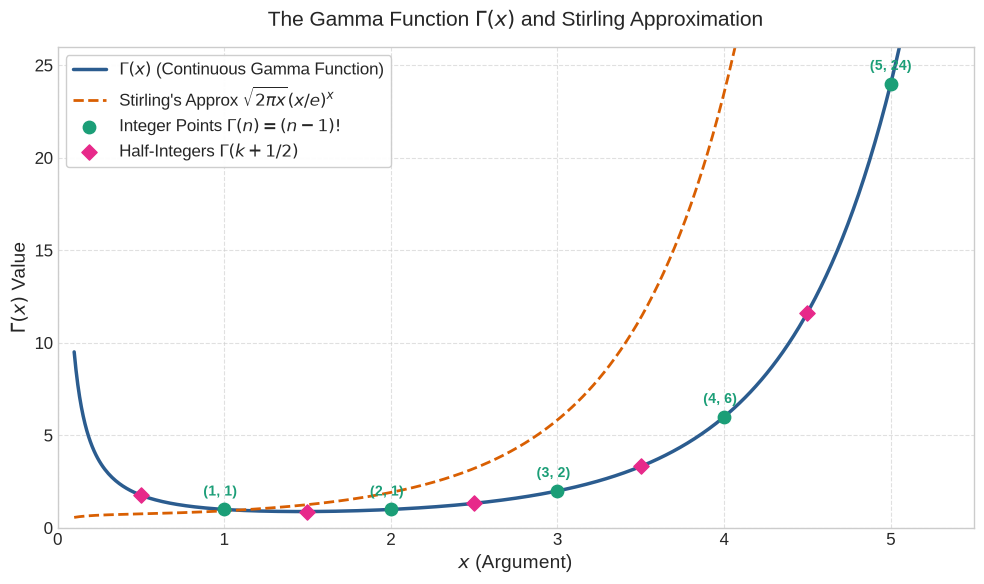

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as scipy_gamma

# Configure presentation styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.autolayout': True
})

# Define domain for continuous Gamma curve
x_vals = np.linspace(0.1, 5.5, 500)
gamma_vals = scipy_gamma(x_vals)

# Stirling's approximation over the continuous domain
stirling_vals = np.sqrt(2 * np.pi * x_vals) * (x_vals / np.e)**x_vals

# Integer factorial points Gamma(n) = (n-1)!
int_n = np.array([1, 2, 3, 4, 5])
int_gamma = scipy_gamma(int_n)

# Half-integer points
half_n = np.array([0.5, 1.5, 2.5, 3.5, 4.5])
half_gamma = scipy_gamma(half_n)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot continuous Gamma and Stirling curves
ax.plot(x_vals, gamma_vals, label=r'$\Gamma(x)$ (Continuous Gamma Function)', color='#2b5c8f', lw=2.5)
ax.plot(x_vals, stirling_vals, label=r"Stirling's Approx $\sqrt{2\pi x}(x/e)^x$", color='#d95f02', lw=2.0, linestyle='--')

# Highlight integer factorial points
ax.scatter(int_n, int_gamma, color='#1b9e77', s=80, zorder=5, label=r'Integer Points $\Gamma(n) = (n-1)!$')
for n, val in zip(int_n, int_gamma):
    ax.annotate(f'({n}, {int(val)})', (n, val), textcoords="offset points", xytext=(-15, 10), 
                fontsize=10, fontweight='bold', color='#1b9e77')

# Highlight half-integer points
ax.scatter(half_n, half_gamma, color='#e7298a', s=60, zorder=5, marker='D', label=r'Half-Integers $\Gamma(k + 1/2)$')

# Formatting and labels
ax.set_title(r'The Gamma Function $\Gamma(x)$ and Stirling Approximation', pad=15)
ax.set_xlabel('$x$ (Argument)')
ax.set_ylabel(r'$\Gamma(x)$ Value')
ax.set_xlim(0, 5.5)
ax.set_ylim(0, 26)
ax.legend(loc='upper left', frameon=True, framealpha=0.95)
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 2\. The Gamma Distribution

By normalizing the integrand of the Euler Gamma function, we obtain a versatile two-parameter continuous probability distribution over $(0, \infty)$.

::: {#def-gamma-distribution}
## The Gamma Probability Density Function (Shape-Rate Parameterization)
A continuous random variable $Y$ is said to follow the **Gamma distribution** with **shape parameter** $a > 0$ and **rate parameter** $\lambda > 0$, denoted $Y \sim \text{Gamma}(a, \lambda)$, if its probability density function (PDF) is given by:
$$
f_Y(y) = \frac{1}{\Gamma(a)} (\lambda y)^a e^{-\lambda y} \frac{1}{y} = \frac{\lambda^a}{\Gamma(a)} y^{a-1} e^{-\lambda y}, \quad \text{for } y > 0
$$
For $y \le 0$, $f_Y(y) = 0$.
:::

::: {.callout-tip collapse="true"}
## Proof of Gamma PDF via Scaling Transformation
We first verify that the standard unscaled Gamma distribution $X \sim \text{Gamma}(a, 1)$ possesses a valid density integrating to unity. By definition of the Gamma function:
$$
1 = \frac{1}{\Gamma(a)} \int_0^\infty x^a e^{-x} \frac{dx}{x} = \int_0^\infty \frac{1}{\Gamma(a)} x^{a-1} e^{-x} dx
$$
Thus, $f_X(x) = \frac{1}{\Gamma(a)} x^{a-1} e^{-x}$ for $x > 0$ is a valid probability density function.

To introduce the rate parameter $\lambda > 0$, we perform a linear scaling transformation of random variables (`[Transformations of Random Variables](transformations-and-convolutions.ipynb)`). Let $Y = \frac{X}{\lambda}$.

We find the inverse function and its derivative:
$$
\begin{aligned}
y &= \frac{x}{\lambda} \implies x = \lambda y \\
\frac{dx}{dy} &= \lambda
\end{aligned}
$$

By the change of variables formula for continuous densities, the PDF of $Y$ is:
$$
\begin{aligned}
f_Y(y) &= f_X(x(y)) \left| \frac{dx}{dy} \right| \\
&= \left( \frac{1}{\Gamma(a)} (\lambda y)^{a-1} e^{-\lambda y} \right) \times \lambda \\
&= \frac{1}{\Gamma(a)} \lambda^{a-1} y^{a-1} e^{-\lambda y} \cdot \lambda \\
&= \frac{\lambda^a}{\Gamma(a)} y^{a-1} e^{-\lambda y}, \quad y > 0
\end{aligned}
$$
This confirms that $Y \sim \text{Gamma}(a, \lambda)$ is properly normalized over $(0, \infty)$. $\blacksquare$
:::

::: {.callout-warning}
## Shape-Rate vs. Shape-Scale Parameterization
In statistics and econometrics, the Gamma distribution is sometimes parameterized using a **scale parameter** $\theta = \frac{1}{\lambda} > 0$ rather than the rate parameter $\lambda$. Under the $(a, \theta)$ shape-scale parameterization, the density is written as:
$$
f_Y(y; a, \theta) = \frac{1}{\Gamma(a) \theta^a} y^{a-1} e^{-y/\theta}, \quad y > 0
$$
Always check explicitly whether $\lambda$ represents the arrival **rate** (inverse time units, multiplying $y$ inside the exponential) or the **scale** (time units, dividing $y$ inside the exponential) to prevent reciprocal errors in calculations.
:::

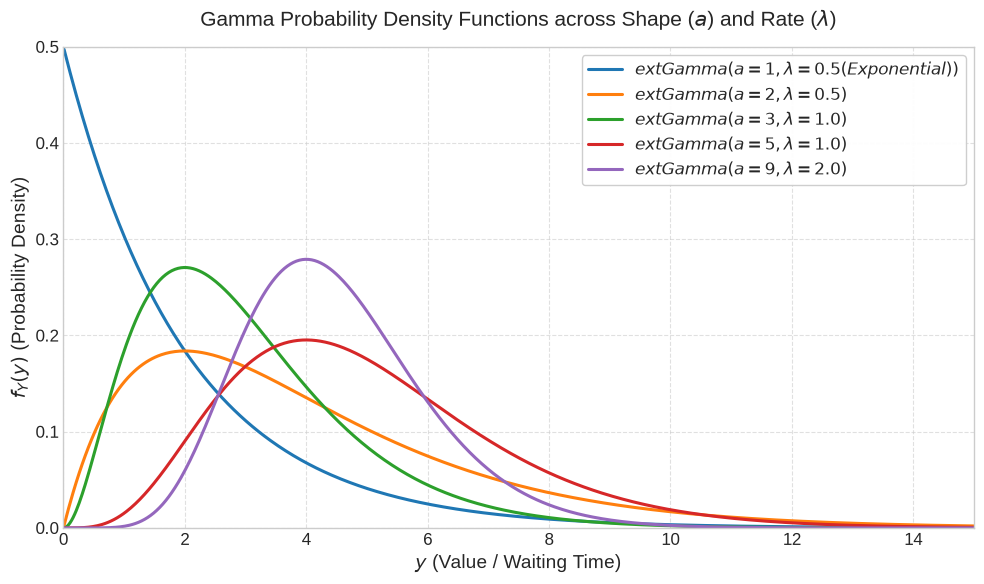

In [3]:
# Plotting Gamma probability density functions for various parameters
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as scipy_gamma

y_vals = np.linspace(0.01, 15.0, 600)

# Define parameter pairs (shape a, rate lambda)
params = [
    (1.0, 0.5, 'a=1, \lambda=0.5 (Exponential)'),
    (2.0, 0.5, 'a=2, \lambda=0.5'),
    (3.0, 1.0, 'a=3, \lambda=1.0'),
    (5.0, 1.0, 'a=5, \lambda=1.0'),
    (9.0, 2.0, 'a=9, \lambda=2.0')
]

fig, ax = plt.subplots(figsize=(10, 6))

for a, lam, label in params:
    # Compute PDF using analytical formula
    pdf_vals = (lam**a / scipy_gamma(a)) * (y_vals**(a - 1)) * np.exp(-lam * y_vals)
    ax.plot(y_vals, pdf_vals, label=f'$\text{{Gamma}}({label})$', lw=2.2)

ax.set_title(r'Gamma Probability Density Functions across Shape ($a$) and Rate ($\lambda$)', pad=15)
ax.set_xlabel('$y$ (Value / Waiting Time)')
ax.set_ylabel('$f_Y(y)$ (Probability Density)')
ax.set_xlim(0, 15)
ax.set_ylim(0, 0.5)
ax.legend(loc='upper right', frameon=True, framealpha=0.95)
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

## 3\. Gamma-Exponential Connection and Poisson Processes

The most fundamental physical origin of the Gamma distribution arises from continuous arrival processes, specifically the **[Poisson Process](poisson-distribution.ipynb)**.

::: {#thm-gamma-expo-poisson}
## Arrival Times in a Poisson Process (Erlang Distribution)
Consider a homogeneous Poisson process with constant arrival rate $\lambda > 0$, where $N_t$ denotes the number of arrivals up to continuous time $t > 0$. If $X_1, X_2, \dots, X_n$ denote the independent inter-arrival times between consecutive arrivals, then:
1. Each individual inter-arrival time $X_j$ is independent and identically distributed ([independent random variables](independence-of-rvs.ipynb)) according to an **[Exponential Distribution](exponential-distribution.ipynb)**: $X_j \stackrel{\text{i.i.d.}}{\sim} \text{Expo}(\lambda)$.
2. The waiting time until the $n$-th arrival, $T_n = \sum_{j=1}^n X_j$, follows exactly a **Gamma distribution** with integer shape parameter $n$ and rate parameter $\lambda$:
$$
T_n \sim \text{Gamma}(n, \lambda)
$$
*(When the shape parameter $n \in \mathbb{N}$ is an integer, this distribution is also called the **Erlang distribution**).*
:::

::: {.callout-tip collapse="true"}
## Proof of Exponential Waiting Times and Gamma Sum of Arrivals
First, we establish the distribution of the first arrival time $T_1 = X_1$. In a Poisson process with rate $\lambda$, the number of arrivals $N_t$ in the interval $[0, t]$ follows a Poisson distribution with mean $\lambda t$:
$$
P(N_t = k) = \frac{(\lambda t)^k e^{-\lambda t}}{k!}, \quad k = 0, 1, 2, \dots
$$

Notice that the event $\{T_1 > t\}$ (the first arrival occurs after time $t$) happens if and only if exactly zero arrivals occur in the time interval $[0, t]$. Therefore:
$$
P(T_1 > t) = P(N_t = 0) = \frac{(\lambda t)^0 e^{-\lambda t}}{0!} = e^{-\lambda t}
$$

Thus, the cumulative distribution function ([Cumulative Distribution Function](cumulative-distribution-functions.ipynb)) of $T_1$ for $t > 0$ is:
$$
F_{T_1}(t) = P(T_1 \le t) = 1 - P(T_1 > t) = 1 - e^{-\lambda t}
$$

Differentiating with respect to $t$ yields the PDF ([Probability Density Function](probability-density-function.ipynb)):
$$
f_{T_1}(t) = \frac{d}{dt} F_{T_1}(t) = \lambda e^{-\lambda t}, \quad t > 0
$$
Which proves that $T_1 = X_1 \sim \text{Expo}(\lambda)$. By the stationary and independent increments property of the Poisson process (the **memoryless property**), every consecutive inter-arrival gap $X_j$ is independently and identically distributed as $\text{Expo}(\lambda)$.

We now prove that $T_n = \sum_{j=1}^n X_j \sim \text{Gamma}(n, \lambda)$. Notice again that the $n$-th arrival occurs after time $t$ ($\{T_n > t\}$) if and only if strictly fewer than $n$ arrivals occur during $[0, t]$:
$$
P(T_n > t) = P(N_t < n) = \sum_{k=0}^{n-1} P(N_t = k) = \sum_{k=0}^{n-1} \frac{(\lambda t)^k e^{-\lambda t}}{k!}
$$

To find the probability density function $f_{T_n}(t)$, we differentiate the CDF $F_{T_n}(t) = 1 - P(T_n > t)$ with respect to $t$:
$$
\begin{aligned}
f_{T_n}(t) &= -\frac{d}{dt} \left[ e^{-\lambda t} \sum_{k=0}^{n-1} \frac{(\lambda t)^k}{k!} \right] \\
&= -\left( -\lambda e^{-\lambda t} \sum_{k=0}^{n-1} \frac{(\lambda t)^k}{k!} + e^{-\lambda t} \sum_{k=1}^{n-1} \frac{k \lambda^k t^{k-1}}{k!} \right) \\
&= \lambda e^{-\lambda t} \left( \sum_{k=0}^{n-1} \frac{(\lambda t)^k}{k!} - \sum_{k=1}^{n-1} \frac{(\lambda t)^{k-1}}{(k-1)!} \right)
\end{aligned}
$$

Notice that the two summations inside the parentheses form a perfect telescoping series. Let $j = k-1$ in the second sum:
$$
\sum_{k=0}^{n-1} \frac{(\lambda t)^k}{k!} - \sum_{j=0}^{n-2} \frac{(\lambda t)^j}{j!} = \frac{(\lambda t)^{n-1}}{(n-1)!}
$$

Multiplying by the outside factor $\lambda e^{-\lambda t}$ and recognizing $(n-1)! = \Gamma(n)$:
$$
f_{T_n}(t) = \lambda e^{-\lambda t} \frac{(\lambda t)^{n-1}}{(n-1)!} = \frac{\lambda^n}{\Gamma(n)} t^{n-1} e^{-\lambda t}, \quad t > 0
$$
This is precisely the density of $\text{Gamma}(n, \lambda)$. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Discrete vs. Continuous Analogy
There is a profound exact structural correspondence between discrete-time counting trials and continuous-time arrival processes:

- **Gamma is the continuous analogue of the [Negative Binomial Distribution](geometric-and-negative-binomial-dist.ipynb):**
  While the Negative Binomial distribution models the *discrete number of trials* needed to observe the $n$-th success in independent Bernoulli trials, the Gamma (Erlang) distribution models the *continuous waiting time* needed to observe the $n$-th arrival in a Poisson process.
- **Exponential is the continuous analogue of the [Geometric Distribution](geometric-and-negative-binomial-dist.ipynb):**
  While the Geometric distribution models the *discrete number of trials* until the $1$st success, the Exponential distribution models the *continuous waiting time* until the $1$st arrival. Both uniquely possess the memoryless property in their respective domains.
:::

### 3.1\. Moment Generating Function and Sums of Independent Exponentials

We can alternatively prove the sum identity using the powerful machinery of **[Moment Generating Functions](moment-generating-functions.ipynb)** (MGFs), which uniquely determine probability distributions.

::: {#thm-mgf-gamma-expo}
## MGF of Sums of Exponentials
Let $X_1, X_2, \dots, X_n \stackrel{\text{i.i.d.}}{\sim} \text{Expo}(1)$ be independent standard exponential random variables. The moment generating function of their sum $T_n = \sum_{j=1}^n X_j$ matches exactly the moment generating function of a random variable $Y \sim \text{Gamma}(n, 1)$, proving $T_n \stackrel{d}{=} Y$.
:::

::: {.callout-tip collapse="true"}
## Proof of MGF Equivalence between Sum of Exponentials and Gamma
We first compute the moment generating function $M_{X_1}(t) = E[e^{t X_1}]$ for a single standard exponential random variable $X_1 \sim \text{Expo}(1)$ with PDF $f(x) = e^{-x}$:
$$
\begin{aligned}
M_{X_1}(t) &= \int_0^\infty e^{tx} e^{-x} dx \\
&= \int_0^\infty e^{-(1-t)x} dx
\end{aligned}
$$

For the integral to converge, we require $1 - t > 0 \implies t < 1$. Evaluating the integral:
$$
M_{X_1}(t) = \left[ -\frac{e^{-(1-t)x}}{1-t} \right]_0^\infty = 0 - \left( -\frac{1}{1-t} \right) = \frac{1}{1-t}, \quad \text{for } t < 1
$$

Since $T_n = \sum_{j=1}^n X_j$ is the sum of $n$ independent random variables, the MGF of $T_n$ is the product of their individual MGFs:
$$
M_{T_n}(t) = \prod_{j=1}^n M_{X_j}(t) = \left( \frac{1}{1-t} \right)^n, \quad \text{for } t < 1
$$

Now let $Y \sim \text{Gamma}(n, 1)$ have density $f_Y(y) = \frac{1}{\Gamma(n)} y^{n-1} e^{-y}$ for $y > 0$. We compute its moment generating function $M_Y(t) = E[e^{t Y}]$ directly via the [Law of the Unconscious Statistician (LOTUS)](lotus.ipynb):
$$
\begin{aligned}
E[e^{t Y}] &= \int_0^\infty e^{ty} f_Y(y) dy \\
&= \int_0^\infty e^{ty} \frac{1}{\Gamma(n)} y^n e^{-y} \frac{dy}{y} \\
&= \frac{1}{\Gamma(n)} \int_0^\infty y^{n-1} e^{-(1-t)y} dy
\end{aligned}
$$

To evaluate this integral for $t < 1$, we introduce the substitution $x = (1-t)y$:
$$
\begin{aligned}
y &= \frac{x}{1-t} \\
dy &= \frac{dx}{1-t}
\end{aligned}
$$

Substituting into the integral:
$$
\begin{aligned}
E[e^{t Y}] &= \frac{1}{\Gamma(n)} \int_0^\infty \left(\frac{x}{1-t}\right)^{n-1} e^{-x} \frac{dx}{1-t} \\
&= \frac{1}{\Gamma(n)} \frac{1}{(1-t)^n} \int_0^\infty x^{n-1} e^{-x} dx
\end{aligned}
$$

Recognizing $\int_0^\infty x^{n-1} e^{-x} dx = \Gamma(n)$, the factors cancel:
$$
M_Y(t) = \frac{1}{\Gamma(n)} \frac{1}{(1-t)^n} \Gamma(n) = \left( \frac{1}{1-t} \right)^n, \quad \text{for } t < 1
$$

Since $M_{T_n}(t) = M_Y(t) = (1-t)^{-n}$ on an open interval around $t = 0$, by the one-to-one uniqueness property of moment generating functions, $T_n \stackrel{d}{=} Y \sim \text{Gamma}(n, 1)$.

By scaling by $1/\lambda$, for $X_j \sim \text{Expo}(\lambda)$, $M_{X_j}(t) = \frac{\lambda}{\lambda - t} = \left(1 - \frac{t}{\lambda}\right)^{-1}$, giving $M_{T_n}(t) = \left(1 - \frac{t}{\lambda}\right)^{-n}$, which exactly matches $\text{Gamma}(n, \lambda)$. $\blacksquare$
:::

## 4\. Moments of the Gamma Distribution via LOTUS

Using the definition of the Gamma integral, computing any raw moment of a Gamma random variable becomes a clean, one-step calculation without requiring cumbersome integration by parts.

::: {#prp-gamma-moments}
## Raw Moments, Mean, and Variance of the Gamma Distribution
Let $X \sim \text{Gamma}(a, 1)$ be an unscaled Gamma random variable. For any real exponent $c > -a$, the $c$-th raw moment is:
$$
E[X^c] = \frac{\Gamma(a+c)}{\Gamma(a)}
$$
For the general scaled distribution $Y \sim \text{Gamma}(a, \lambda)$, the expected value ([Expected Value](expectation.ipynb)) and variance ([Variance](variance.ipynb)) are given by:
$$
E[Y] = \frac{a}{\lambda}, \quad \text{Var}(Y) = \frac{a}{\lambda^2}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Gamma Moments, Mean, and Variance via LOTUS
Let $X \sim \text{Gamma}(a, 1)$. By the [Law of the Unconscious Statistician (LOTUS)](lotus.ipynb), the expectation of the function $g(X) = X^c$ is given by integrating against the density of $X$:
$$
\begin{aligned}
E[X^c] &= \int_0^\infty x^c f_X(x) dx \\
&= \int_0^\infty x^c \frac{1}{\Gamma(a)} x^a e^{-x} \frac{dx}{x} \\
&= \frac{1}{\Gamma(a)} \int_0^\infty x^{a+c-1} e^{-x} dx
\end{aligned}
$$

For convergence at the origin $x=0$, we require the exponent $a+c-1 > -1 \implies a+c > 0$. Under this condition, the integral $\int_0^\infty x^{a+c-1} e^{-x} dx$ is precisely the defining integral of $\Gamma(a+c)$. Therefore:
$$
E[X^c] = \frac{\Gamma(a+c)}{\Gamma(a)}, \quad \text{if } a+c > 0
$$

We now evaluate the first two integer moments ($c=1$ and $c=2$):

For the first moment ($c=1$):
$$
E[X] = \frac{\Gamma(a+1)}{\Gamma(a)} = \frac{a \Gamma(a)}{\Gamma(a)} = a
$$

For the second moment ($c=2$):
$$
E[X^2] = \frac{\Gamma(a+2)}{\Gamma(a)} = \frac{(a+1)\Gamma(a+1)}{\Gamma(a)} = \frac{(a+1)a\Gamma(a)}{\Gamma(a)} = a^2 + a
$$

Using the variance formula $\text{Var}(X) = E[X^2] - (E[X])^2$:
$$
\text{Var}(X) = (a^2 + a) - a^2 = a
$$

Finally, for the general scaled variable $Y = \frac{X}{\lambda} \sim \text{Gamma}(a, \lambda)$, we apply the linearity of expectation and the quadratic scaling of variance:
$$
\begin{aligned}
E[Y] &= E\left[ \frac{X}{\lambda} \right] = \frac{1}{\lambda} E[X] = \frac{a}{\lambda} \\
\text{Var}(Y) &= \text{Var}\left( \frac{X}{\lambda} \right) = \frac{1}{\lambda^2} \text{Var}(X) = \frac{a}{\lambda^2}
\end{aligned}
$$
This establishes the exact mean and variance expressions. $\blacksquare$
:::

## 5\. Beta-Gamma Connection: The Bank and Post Office Theorem

One of the most remarkable and elegant results in continuous probability theory connects independent Gamma random variables to the **[Beta Distribution](beta-distribution.ipynb)**, simultaneously proving that total duration and fractional time split are **independent**.

::: {#thm-bank-post-office}
## The Bank and Post Office Theorem (Beta-Gamma Connection)
Let $X \sim \text{Gamma}(a, \lambda)$ represent the waiting time at a Bank, and let $Y \sim \text{Gamma}(b, \lambda)$ represent the waiting time at a Post Office. Assume that $X$ and $Y$ are independent random variables ([independent random variables](independence-of-rvs.ipynb)).

Define the total waiting time $T = X + Y$, and the fraction of total time spent at the Bank $W = \frac{X}{X+Y}$. Then:
1. The total waiting time $T$ follows a Gamma distribution:
$$
T \sim \text{Gamma}(a+b, \lambda)
$$
2. The fraction of time spent at the Bank $W$ follows a Beta distribution:
$$
W \sim \text{Beta}(a, b)
$$
3. The random variables $T$ and $W$ are **exactly independent**:
$$
f_{T, W}(t, w) = f_T(t) f_W(w)
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Bank and Post Office Theorem via Jacobian Transformation
Without loss of generality (WLOG), we set $\lambda = 1$. Notice that scaling by $\lambda$ scales $X$ and $Y$ by $1/\lambda$. In the ratio $W = \frac{X}{X+Y} = \frac{X/\lambda}{(X+Y)/\lambda}$, the scale factor $\lambda$ cancels out entirely, so the distribution of $W$ is invariant under $\lambda$. For $T = X+Y$, scaling by $1/\lambda$ simply scales the final sum from $\text{Gamma}(a+b, 1)$ to $\text{Gamma}(a+b, \lambda)$.

Let $X \sim \text{Gamma}(a, 1)$ and $Y \sim \text{Gamma}(b, 1)$ be independent. Their joint density ([Joint Distribution](joint-distribution.ipynb)) for $x > 0, y > 0$ is the product of their marginal densities:
$$
\begin{aligned}
f_{X, Y}(x, y) &= f_X(x) f_Y(y) \\
&= \left( \frac{1}{\Gamma(a)} x^{a-1} e^{-x} \right) \left( \frac{1}{\Gamma(b)} y^{b-1} e^{-y} \right) \\
&= \frac{1}{\Gamma(a)\Gamma(b)} x^{a-1} y^{b-1} e^{-(x+y)}
\end{aligned}
$$

We introduce the 2D transformation of variables $(X, Y) \to (T, W)$:
$$
T = X + Y, \quad W = \frac{X}{X+Y}
$$

We invert this transformation to express $(x, y)$ in terms of $(t, w)$. Since $t = x+y$ and $w = \frac{x}{t}$:
$$
\begin{aligned}
x &= t w \\
y &= t - x = t(1 - w)
\end{aligned}
$$
The domain $x > 0, y > 0$ maps directly to the region $t > 0$ and $0 < w < 1$.

We compute the 2D Jacobian matrix $J = \frac{\partial(x, y)}{\partial(t, w)}$ of partial derivatives:
$$
J = \begin{pmatrix}
\frac{\partial x}{\partial w} & \frac{\partial x}{\partial t} \\
\frac{\partial y}{\partial w} & \frac{\partial y}{\partial t}
\end{pmatrix} = \begin{pmatrix}
t & w \\
-t & 1-w
\end{pmatrix}
$$

The determinant of the Jacobian matrix is:
$$
\det(J) = t(1-w) - (-tw) = t - tw + tw = t
$$
Since $t > 0$, the absolute value of the Jacobian determinant is $|J| = t$.

By the multivariate change of variables theorem, the joint PDF of $(T, W)$ is:
$$
\begin{aligned}
f_{T, W}(t, w) &= f_{X, Y}(x(t, w), y(t, w)) \cdot |J| \\
&= \frac{1}{\Gamma(a)\Gamma(b)} (tw)^{a-1} (t(1-w))^{b-1} e^{-t} \cdot t \\
&= \frac{1}{\Gamma(a)\Gamma(b)} t^{a-1} w^{a-1} t^{b-1} (1-w)^{b-1} t e^{-t} \\
&= \frac{1}{\Gamma(a)\Gamma(b)} w^{a-1} (1-w)^{b-1} t^{a+b-1} e^{-t}
\end{aligned}
$$

To separate this into recognized probability densities, we multiply and divide by $\Gamma(a+b)$:
$$
f_{T, W}(t, w) = \left[ \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} w^{a-1} (1-w)^{b-1} \right] \times \left[ \frac{1}{\Gamma(a+b)} t^{a+b-1} e^{-t} \right], \quad \text{for } 0 < w < 1, \; t > 0
$$

Notice that the expression factors cleanly into two separate functions of $w$ and $t$:
$$
f_{T, W}(t, w) = g(w) \cdot h(t)
$$
where $h(t) = \frac{1}{\Gamma(a+b)} t^{a+b-1} e^{-t}$ is exactly the PDF of $\text{Gamma}(a+b, 1)$, which integrates to $1$ over $t \in (0, \infty)$.

To find the marginal density of $W$, we integrate out $t$:
$$
\begin{aligned}
f_W(w) &= \int_0^\infty f_{T, W}(t, w) dt \\
&= \left[ \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} w^{a-1} (1-w)^{b-1} \right] \int_0^\infty \frac{1}{\Gamma(a+b)} t^{a+b-1} e^{-t} dt \\
&= \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} w^{a-1} (1-w)^{b-1} \times 1 \\
&= \frac{1}{B(a, b)} w^{a-1} (1-w)^{b-1}, \quad 0 < w < 1
\end{aligned}
$$

This is precisely the PDF of $W \sim \text{Beta}(a, b)$, and as a consequence confirms the normalizing Beta integral constant:
$$
\int_0^1 w^{a-1} (1-w)^{b-1} dw = \frac{\Gamma(a)\Gamma(b)}{\Gamma(a+b)} = B(a, b)
$$

Since $f_{T, W}(t, w) = f_W(w) f_T(t)$, the total waiting time $T \sim \text{Gamma}(a+b, 1)$ and the fraction $W \sim \text{Beta}(a, b)$ are strictly independent. Scaling by $1/\lambda$ gives $T \sim \text{Gamma}(a+b, \lambda)$ while leaving $W \sim \text{Beta}(a, b)$ unchanged. $\blacksquare$
:::

::: {.callout-note}
## Intuition: Why are Total Time and Fraction Independent?
Intuitively, knowing that you spent a long *total* time at the Bank and Post Office combined ($T$ is large) tells you nothing about *which* location took the majority of the time ($W$). If $X$ and $Y$ are independent Gamma variables with identical rate parameters $\lambda$, the shape parameters $a$ and $b$ act as relative weights governing the expected split of the time, regardless of whether the overall excursion was long or short.
:::

This independence property provides an incredibly elegant story method to compute the expected value of a Beta random variable without any calculus.

::: {#cor-expected-value-beta}
## Expected Value of a Beta Random Variable
If $W \sim \text{Beta}(a, b)$, its [Expected Value](expectation.ipynb) is given by:
$$
E[W] = \frac{a}{a+b}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Beta Expectation via Both Methods
**Method 1 (Direct LOTUS Calculus):**
We apply LOTUS directly using the Beta PDF:
$$
\begin{aligned}
E[W] &= \int_0^1 w f_W(w) dw \\
&= \int_0^1 w \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} w^{a-1} (1-w)^{b-1} dw \\
&= \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} \int_0^1 w^{(a+1)-1} (1-w)^{b-1} dw
\end{aligned}
$$
The integral $\int_0^1 w^{(a+1)-1} (1-w)^{b-1} dw$ is the normalizing integral of $\text{Beta}(a+1, b)$, which equals $B(a+1, b) = \frac{\Gamma(a+1)\Gamma(b)}{\Gamma(a+b+1)}$. Substituting this back:
$$
E[W] = \frac{\Gamma(a+b)}{\Gamma(a)\Gamma(b)} \frac{\Gamma(a+1)\Gamma(b)}{\Gamma(a+b+1)} = \frac{\Gamma(a+b)}{\Gamma(a)} \frac{a \Gamma(a)}{(a+b)\Gamma(a+b)} = \frac{a}{a+b}
$$

**Method 2 (Bank and Post Office Independence Story):**
Recall from the Bank and Post Office theorem that $W = \frac{X}{X+Y}$ and $T = X + Y$. Notice that we can write $X$ as:
$$
X = W (X + Y) = W \cdot T
$$
Since $W$ and $T$ are **independent random variables** by Theorem 5, the expectation of their product equals the product of their expectations ([independence of random variables](independence-of-rvs.ipynb)):
$$
E[X] = E[W \cdot T] = E[W] \cdot E[T]
$$
We already know from our Gamma moments (`Proposition 4`) that $X \sim \text{Gamma}(a, \lambda) \implies E[X] = \frac{a}{\lambda}$, and $T \sim \text{Gamma}(a+b, \lambda) \implies E[T] = \frac{a+b}{\lambda}$. Substituting these exact values:
$$
\frac{a}{\lambda} = E[W] \left( \frac{a+b}{\lambda} \right) \implies E[W] = \frac{a}{a+b}
$$
Both methods yield the exact same result. $\blacksquare$
:::

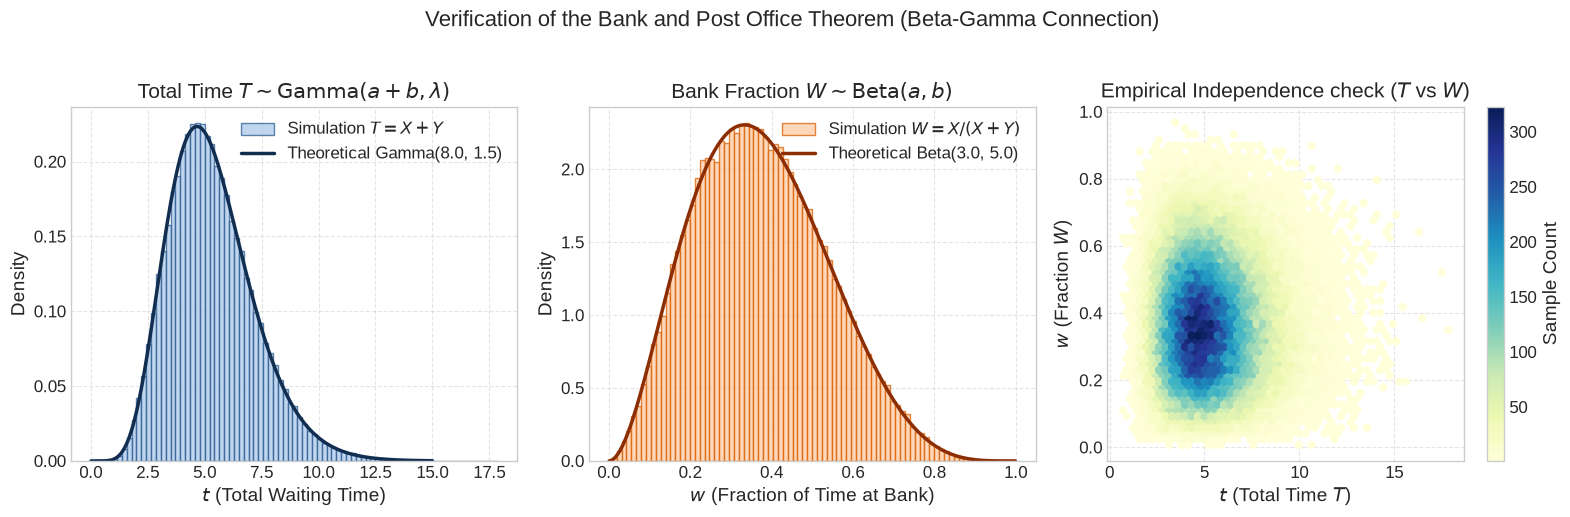

In [4]:
# Simulation verifying the Bank & Post Office Theorem (Beta-Gamma Connection)
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as scipy_gamma

np.random.seed(42)
N = 100_000

# Parameters for Bank (a) and Post Office (b) with common rate lambda
a_param, b_param, lam_param = 3.0, 5.0, 1.5

# Sample independent Gamma variables (numpy uses scale = 1/lambda)
X_samples = np.random.gamma(shape=a_param, scale=1.0/lam_param, size=N)
Y_samples = np.random.gamma(shape=b_param, scale=1.0/lam_param, size=N)

# Compute transformations
T_samples = X_samples + Y_samples
W_samples = X_samples / T_samples

# Create 1x3 verification plots
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total Waiting Time T ~ Gamma(a+b, lambda)
t_grid = np.linspace(0.01, 15, 400)
t_theoretical = (lam_param**(a_param + b_param) / scipy_gamma(a_param + b_param)) * \
                (t_grid**(a_param + b_param - 1)) * np.exp(-lam_param * t_grid)

axs[0].hist(T_samples, bins=80, density=True, color='#abc9ea', edgecolor='#2b5c8f', alpha=0.75, label='Simulation $T=X+Y$')
axs[0].plot(t_grid, t_theoretical, color='#112e51', lw=2.5, label=f'Theoretical Gamma({a_param+b_param}, {lam_param})')
axs[0].set_title(r'Total Time $T \sim \text{Gamma}(a+b, \lambda)$')
axs[0].set_xlabel('$t$ (Total Waiting Time)')
axs[0].set_ylabel('Density')
axs[0].legend(loc='upper right')
axs[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Fraction of Time W ~ Beta(a, b)
w_grid = np.linspace(0.001, 0.999, 400)
beta_const = scipy_gamma(a_param + b_param) / (scipy_gamma(a_param) * scipy_gamma(b_param))
w_theoretical = beta_const * (w_grid**(a_param - 1)) * ((1 - w_grid)**(b_param - 1))

axs[1].hist(W_samples, bins=80, density=True, color='#ffcba4', edgecolor='#d95f02', alpha=0.75, label='Simulation $W=X/(X+Y)$')
axs[1].plot(w_grid, w_theoretical, color='#8c2d04', lw=2.5, label=f'Theoretical Beta({a_param}, {b_param})')
axs[1].set_title(r'Bank Fraction $W \sim \text{Beta}(a, b)$')
axs[1].set_xlabel('$w$ (Fraction of Time at Bank)')
axs[1].set_ylabel('Density')
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Empirical Independence check via 2D Scatter/Hexbin of T vs W
hb = axs[2].hexbin(T_samples, W_samples, gridsize=50, cmap='YlGnBu', mincnt=1)
fig.colorbar(hb, ax=axs[2], label='Sample Count')
axs[2].set_title(r'Empirical Independence check ($T$ vs $W$)')
axs[2].set_xlabel('$t$ (Total Time $T$)')
axs[2].set_ylabel('$w$ (Fraction $W$)')
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Verification of the Bank and Post Office Theorem (Beta-Gamma Connection)', fontsize=16, y=1.03)
plt.show()

> **References & Acknowledgments:**
> Problems and derivations adapted from *Introduction to Probability* by Joseph K. Blitzstein and Jessica Hwang, and classical lecture notes on Gamma distributions, Poisson arrival processes, and the Beta-Gamma connection.